# Notebook Tunggal — Deteksi Phishing XGBoost (5-Fold Cross-Validation)

Satu notebook untuk SEKALI run. Menghasilkan semua yang dibutuhkan skripsi:

1. Tabel perbandingan 6 skenario (S1-S6): URL-Only & FULL pada rasio 70:30, 80:20, 90:10.
2. Confusion matrix untuk skenario 80:20 (S3 = URL-Only, S4 = FULL), disimpan sebagai s3.png & s4.png.
3. File .pkl untuk backend (model URL-Only & FULL dari skenario 80:20).

Seluruh seleksi fitur (RFECV) dan hyperparameter tuning memakai 5-fold GroupKFold (berbasis domain). Cukup jalankan Run All; tidak perlu notebook lain.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.feature_selection import RFECV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, make_scorer, balanced_accuracy_score)
from url_features import extract_url_features, extract_registered_domain, FEATURE_ORDER as URL_FEATURES

RANDOM_STATE = 42
N_FOLD = 5                                   # <<< cross-validation 5-fold
f1_phish = make_scorer(f1_score, pos_label=0)
print('Setup OK. Fitur URL:', len(URL_FEATURES), '| K-Fold:', N_FOLD)

Setup OK. Fitur URL: 41 | K-Fold: 5


In [4]:
# LOAD + BERSIHKAN + BUANG LEAKAGE + BANGUN FITUR (URL & FULL)
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')
df = df.dropna(subset=['label']).drop_duplicates(subset=['URL']).reset_index(drop=True)

# buang fitur penyebab data leakage (target-encoding)
LEAKAGE_COLS = ['URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb']
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns])

# label + grup domain (untuk split & CV berbasis domain)
y = df['label'].astype(int).values
groups = df['URL'].apply(extract_registered_domain).values

# (a) fitur URL = 41 fitur leksikal (dihitung dari string URL via url_features.py)
X_url = pd.DataFrame(df['URL'].apply(extract_url_features).tolist(), columns=URL_FEATURES)

# (b) fitur HTML stabil + (c) FULL = URL + HTML
HTML_STABLE = ['HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon',
               'Robots', 'IsResponsive', 'HasDescription', 'NoOfiFrame',
               'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
               'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
               'HasCopyrightInfo']
html_cols = [c for c in HTML_STABLE if c in df.columns]
X_html = df[html_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
X_full = pd.concat([X_url, X_html], axis=1)

print('X_url :', X_url.shape, '| X_full:', X_full.shape)
print('phishing(0)=', int((y==0).sum()), '| legit(1)=', int((y==1).sum()))

X_url : (235370, 41) | X_full: (235370, 58)
phishing(0)= 100520 | legit(1)= 134850


In [5]:
# FUNGSI PELATIHAN: split per-domain -> RFECV (5-fold) -> tuning (5-fold)
#                  -> train + early stopping -> threshold -> evaluasi
def latih(X, y, groups, test_size, nama):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_STATE)
    tr, te = next(gss.split(X, y, groups=groups))
    Xtr_all, Xte_all = X.iloc[tr].reset_index(drop=True), X.iloc[te].reset_index(drop=True)
    ytr, yte = y[tr], y[te]
    gtr = groups[tr]
    assert len(set(gtr) & set(groups[te])) == 0, 'Domain bocor!'
    spw = 1.0

    rng = np.random.RandomState(RANDOM_STATE)
    si = rng.choice(len(Xtr_all), size=min(50000, len(Xtr_all)), replace=False)

    # (1) Seleksi fitur RFECV (5-fold GroupKFold, data latih saja)
    est = xgb.XGBClassifier(n_estimators=200, learning_rate=0.3, max_depth=10, subsample=0.8,
                            colsample_bytree=0.8, tree_method='hist', eval_metric='logloss',
                            random_state=RANDOM_STATE, n_jobs=-1)
    cv_sel = list(GroupKFold(n_splits=N_FOLD).split(Xtr_all.iloc[si], ytr[si], groups=gtr[si]))
    rfecv = RFECV(est, step=1, min_features_to_select=8, cv=cv_sel, scoring=f1_phish, n_jobs=-1)
    rfecv.fit(Xtr_all.iloc[si], ytr[si])
    fitur = [f for f, k in zip(X.columns, rfecv.support_) if k]
    Xtr, Xte = Xtr_all[fitur], Xte_all[fitur]

    # (2) Hyperparameter tuning (RandomizedSearchCV, 5-fold GroupKFold)
    ti = rng.choice(len(Xtr), size=min(60000, len(Xtr)), replace=False)
    param = {'n_estimators': [300, 400, 500, 600], 'learning_rate': [0.03, 0.05, 0.08, 0.1],
             'max_depth': [4, 5, 6, 7, 8], 'min_child_weight': [1, 3, 5, 7],
             'subsample': [0.7, 0.8, 0.9, 1.0], 'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
             'gamma': [0, 0.1, 0.2, 0.3], 'reg_alpha': [0, 0.1, 0.5, 1.0], 'reg_lambda': [1.0, 2.0, 3.0]}
    srch = RandomizedSearchCV(
        xgb.XGBClassifier(eval_metric='logloss', tree_method='hist', scale_pos_weight=spw,
                          random_state=RANDOM_STATE, n_jobs=1),
        param, n_iter=20, scoring=f1_phish,
        cv=list(GroupKFold(n_splits=N_FOLD).split(Xtr.iloc[ti], ytr[ti], groups=gtr[ti])),
        n_jobs=-1, random_state=RANDOM_STATE)
    srch.fit(Xtr.iloc[ti], ytr[ti])
    bp = srch.best_params_

    # (3) Train final + early stopping (validasi per-domain)
    gv = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    ai, vi = next(gv.split(Xtr, ytr, groups=gtr))
    fp = dict(n_estimators=1000, learning_rate=0.05, max_depth=6, min_child_weight=5,
              subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0, gamma=0.1)
    fp.update(bp); fp['n_estimators'] = max(fp.get('n_estimators', 600), 1000)
    model = xgb.XGBClassifier(**fp, scale_pos_weight=spw, eval_metric='logloss',
                              early_stopping_rounds=50, tree_method='hist',
                              random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(Xtr.iloc[ai], ytr[ai], eval_set=[(Xtr.iloc[vi], ytr[vi])], verbose=False)

    # (4) Threshold via balanced accuracy (di data validasi)
    vp = model.predict_proba(Xtr.iloc[vi])[:, 0]
    cand = np.linspace(0.2, 0.8, 61)
    thr = float(cand[int(np.argmax([balanced_accuracy_score(ytr[vi], np.where(vp >= t, 0, 1)) for t in cand]))])

    # (5) Evaluasi di data uji
    pph = model.predict_proba(Xte)[:, 0]
    yp = np.where(pph >= thr, 0, 1)
    return {'nama': nama, 'model': model, 'fitur': fitur, 'threshold': thr, 'n_fitur': len(fitur),
            'acc': accuracy_score(yte, yp), 'precision': precision_score(yte, yp, pos_label=0),
            'recall': recall_score(yte, yp, pos_label=0), 'f1': f1_score(yte, yp, pos_label=0),
            'cm': confusion_matrix(yte, yp, labels=[0, 1])}

print('Fungsi latih siap (5-fold cross-validation).')

Fungsi latih siap (5-fold cross-validation).


In [6]:
# JALANKAN 6 SKENARIO (sekali run) -> tabel S1-S6
SKEN = [('S1', 'URL-Only', X_url, 0.3), ('S2', 'FULL (URL+HTML)', X_full, 0.3),
        ('S3', 'URL-Only', X_url, 0.2), ('S4', 'FULL (URL+HTML)', X_full, 0.2),
        ('S5', 'URL-Only', X_url, 0.1), ('S6', 'FULL (URL+HTML)', X_full, 0.1)]

hasil, simpan = [], {}
for kode, nama, Xset, ts in SKEN:
    split_str = str(int(round((1 - ts) * 100))) + ':' + str(int(round(ts * 100)))
    print('=== ' + kode + ' | ' + nama + ' | split ' + split_str + ' ===')
    r = latih(Xset, y, groups, ts, nama)
    r['kode'] = kode; r['split'] = split_str
    hasil.append(r)
    simpan[kode] = r
    print('   Acc=' + str(round(r['acc']*100, 2)) + '  Prec=' + str(round(r['precision']*100, 2)) +
          '  Rec=' + str(round(r['recall']*100, 2)) + '  F1=' + str(round(r['f1']*100, 2)) +
          '  (' + str(r['n_fitur']) + ' fitur)')

tabel = pd.DataFrame([{'Skenario': h['kode'], 'Fitur': h['nama'], 'Split': h['split'],
                       'Acc (%)': round(h['acc']*100, 2), 'Prec (%)': round(h['precision']*100, 2),
                       'Rec (%)': round(h['recall']*100, 2), 'F1 (%)': round(h['f1']*100, 2),
                       'Jml Fitur': h['n_fitur']} for h in hasil])
print()
print('=== TABEL HASIL UJI COBA (5-fold CV) ===')
print(tabel.to_string(index=False))

=== S1 | URL-Only | split 70:30 ===
   Acc=98.03  Prec=98.7  Rec=97.0  F1=97.84  (19 fitur)
=== S2 | FULL (URL+HTML) | split 70:30 ===
   Acc=99.46  Prec=99.36  Rec=99.47  F1=99.42  (28 fitur)
=== S3 | URL-Only | split 80:20 ===
   Acc=97.8  Prec=98.96  Rec=96.59  F1=97.76  (17 fitur)
=== S4 | FULL (URL+HTML) | split 80:20 ===
   Acc=99.61  Prec=99.72  Rec=99.5  F1=99.61  (31 fitur)
=== S5 | URL-Only | split 90:10 ===
   Acc=98.53  Prec=99.2  Rec=97.32  F1=98.25  (23 fitur)
=== S6 | FULL (URL+HTML) | split 90:10 ===
   Acc=99.68  Prec=99.61  Rec=99.63  F1=99.62  (32 fitur)

=== TABEL HASIL UJI COBA (5-fold CV) ===
Skenario           Fitur Split  Acc (%)  Prec (%)  Rec (%)  F1 (%)  Jml Fitur
      S1        URL-Only 70:30    98.03     98.70    97.00   97.84         19
      S2 FULL (URL+HTML) 70:30    99.46     99.36    99.47   99.42         28
      S3        URL-Only 80:20    97.80     98.96    96.59   97.76         17
      S4 FULL (URL+HTML) 80:20    99.61     99.72    99.50   99.61

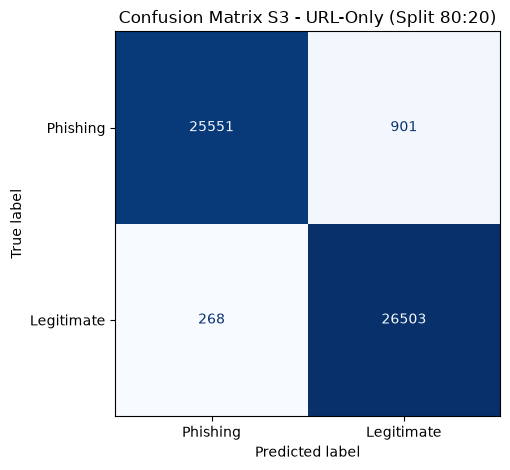

S3 disimpan -> s3.png  | cm = [[25551, 901], [268, 26503]]


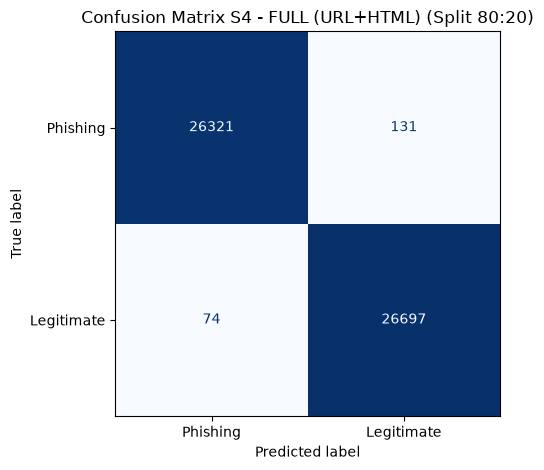

S4 disimpan -> s4.png  | cm = [[26321, 131], [74, 26697]]


In [7]:
# CONFUSION MATRIX SKENARIO 80:20 (S3 = URL-Only, S4 = FULL) + simpan gambar
for kode in ['S3', 'S4']:
    r = simpan[kode]
    disp = ConfusionMatrixDisplay(r['cm'], display_labels=['Phishing', 'Legitimate'])
    disp.plot(cmap='Blues', colorbar=False)
    plt.title('Confusion Matrix ' + kode + ' - ' + r['nama'] + ' (Split 80:20)')
    plt.tight_layout()
    plt.savefig(kode.lower() + '.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(kode + ' disimpan -> ' + kode.lower() + '.png  | cm =', r['cm'].tolist())

In [8]:
# EXPORT .pkl UNTUK BACKEND (dari skenario 80:20: S3 = URL-Only, S4 = FULL)
joblib.dump(simpan['S3']['model'],     'model_xgboost_url.pkl')
joblib.dump(simpan['S3']['fitur'],     'url_feature_schema.pkl')
joblib.dump(simpan['S3']['threshold'], 'decision_threshold.pkl')

joblib.dump(simpan['S4']['model'],     'model_xgboost_dataset.pkl')
joblib.dump(simpan['S4']['fitur'],     'dataset_feature_schema.pkl')
joblib.dump(simpan['S4']['threshold'], 'dataset_threshold.pkl')

print('Export .pkl selesai (6 file): model URL-Only + model FULL siap dipakai app.py.')
print('URL-Only :', simpan['S3']['n_fitur'], 'fitur, thr=', round(simpan['S3']['threshold'], 3))
print('FULL     :', simpan['S4']['n_fitur'], 'fitur, thr=', round(simpan['S4']['threshold'], 3))

Export .pkl selesai (6 file): model URL-Only + model FULL siap dipakai app.py.
URL-Only : 17 fitur, thr= 0.35
FULL     : 31 fitur, thr= 0.46


In [9]:
# UJI DETEKSI — cek apakah model sudah benar mendeteksi phishing
# (pakai model URL-Only di memori, S3; cepat, tanpa scrape/internet)
m, fitur_s, thr_s = simpan['S3']['model'], simpan['S3']['fitur'], simpan['S3']['threshold']
idx0 = list(m.classes_).index(0)   # kolom probabilitas kelas 0 = phishing

# Daftar URL uji + label yang DIHARAPKAN
uji = [
    ('https://www.google.com', 'legitimate'),
    ('https://github.com', 'legitimate'),
    ('https://en.wikipedia.org/wiki/Phishing', 'legitimate'),
    ('https://www.tokopedia.com', 'legitimate'),
    ('http://login-verify-account.security-update.tk/webscr?cmd=update', 'phishing'),
    ('http://192.168.0.10/confirm-account/update.php', 'phishing'),
    ('http://paypal.com.verify-login.secure-update.gq/signin', 'phishing'),
    ('http://bit.ly-account-verify.com/login@signin', 'phishing'),
]

rows = []
for u, harapan in uji:
    fitur_val = pd.DataFrame([extract_url_features(u)])[fitur_s]
    p = float(m.predict_proba(fitur_val)[0][idx0])
    pred = 'phishing' if p >= thr_s else 'legitimate'
    rows.append({'URL': u[:52], 'Harapan': harapan, 'Prediksi': pred,
                 'P(phish)': round(p, 3), 'Match': 'OK' if pred == harapan else 'XX'})

tab = pd.DataFrame(rows)
print(tab.to_string(index=False))
benar = (tab['Match'] == 'OK').sum()
print()
print('Benar', benar, 'dari', len(tab), '->', round(benar / len(tab) * 100, 1), 'persen')

                                                 URL    Harapan   Prediksi  P(phish) Match
                              https://www.google.com legitimate legitimate     0.028    OK
                                  https://github.com legitimate legitimate     0.028    OK
              https://en.wikipedia.org/wiki/Phishing legitimate   phishing     1.000    XX
                           https://www.tokopedia.com legitimate legitimate     0.011    OK
http://login-verify-account.security-update.tk/websc   phishing   phishing     1.000    OK
      http://192.168.0.10/confirm-account/update.php   phishing   phishing     1.000    OK
http://paypal.com.verify-login.secure-update.gq/sign   phishing   phishing     1.000    OK
       http://bit.ly-account-verify.com/login@signin   phishing   phishing     1.000    OK

Benar 7 dari 8 -> 87.5 persen
